In [1]:
from typing import TypedDict

from langgraph.graph import StateGraph
from IPython.display import Image, display

In [2]:
class AgentState(TypedDict):
    name: str
    age: int
    final: str

In [3]:
def first_node(state: AgentState) -> AgentState:
    """This is the first node of our sequence"""
    state["final"] = f"Hi {state["name"]}!"
    return state

def second_node(state: AgentState) -> AgentState:
    """This is the second node of our sequence"""
    state["final"] = f"{state["final"]} \nYou are {state["age"]} years old."
    return state

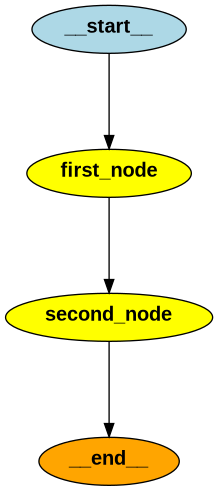

In [4]:
graph = StateGraph(
    state_schema=AgentState
)

graph.add_node(node="first_node", action=first_node)
graph.add_node(node="second_node", action=second_node)
graph.set_entry_point(key="first_node")
graph.add_edge(start_key="first_node", end_key="second_node")
graph.set_finish_point(key="second_node")

app = graph.compile()

display(Image(app.get_graph().draw_png()))

In [5]:
result = app.invoke(input={"name": "Rajesh", "age": 24})

In [6]:
result

{'name': 'Rajesh', 'age': 24, 'final': 'Hi Rajesh! \nYou are 24 years old.'}